# Train 30 Models

In [9]:
import torch
import numpy as np
from torch.optim import AdamW
from nanochat.gpt import GPT, GPTConfig
import os

# ==========================================
# 1. Shared Numerical Solvers
# ==========================================
def rk4_step(func, state, t, dt, **kwargs):
    """Generic Runge-Kutta 4 integration step."""
    k1 = func(state, t, **kwargs)
    k2 = func(state + 0.5 * dt * k1, t + 0.5 * dt, **kwargs)
    k3 = func(state + 0.5 * dt * k2, t + 0.5 * dt, **kwargs)
    k4 = func(state + dt * k3, t + dt, **kwargs)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# ==========================================
# 2. Physics Data Generation Functions
# ==========================================

# --- Task 1: Lotka-Volterra (Predator-Prey) ---
def lotka_volterra_dynamics(state, t, a=1.5, b=1.0, c=3.0, d=1.0):
    x, y = state[..., 0], state[..., 1]
    dxdt = a*x - b*x*y
    dydt = -c*y + d*x*y
    return torch.stack([dxdt, dydt], dim=-1)

def generate_lotka_volterra(B=2048, T=64, dt=0.1):
    print(f"Generating Lotka-Volterra data (B={B}, T={T})...")
    state = torch.rand(B, 2) * 2.0 + 0.5
    trajectory = [state]
    t = 0.0
    for _ in range(T):
        state = rk4_step(lotka_volterra_dynamics, state, t, dt)
        trajectory.append(state)
        t += dt
    return torch.stack(trajectory, dim=1)

# --- Task 2: Lorenz System (Chaotic Attractor) ---
def lorenz_dynamics(state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state[..., 0], state[..., 1], state[..., 2]
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return torch.stack([dxdt, dydt, dzdt], dim=-1)

def generate_lorenz(B=2048, T=64, dt=0.01):
    print(f"Generating Lorenz System data (B={B}, T={T})...")
    state = torch.randn(B, 3) 
    trajectory = [state]
    t = 0.0
    for _ in range(T):
        state = rk4_step(lorenz_dynamics, state, t, dt)
        trajectory.append(state)
        t += dt
    return torch.stack(trajectory, dim=1)

# --- Task 3: Kinematic Bicycle Model ---
def generate_bicycle_model(B=2048, T=64, dt=0.1, L=2.5):
    print(f"Generating Kinematic Bicycle data (B={B}, T={T})...")
    x = torch.zeros(B)
    y = torch.zeros(B)
    theta = torch.rand(B) * 2 * np.pi
    delta = torch.zeros(B)
    
    v = torch.rand(B) * 10 + 5 
    phi = (torch.rand(B) - 0.5) * 0.4
    
    trajectory = []
    curr_state = torch.stack([x, y, theta, delta], dim=1)
    trajectory.append(curr_state)
    
    for _ in range(T):
        _x, _y, _theta, _delta = curr_state[:,0], curr_state[:,1], curr_state[:,2], curr_state[:,3]
        dx = v * torch.cos(_theta)
        dy = v * torch.sin(_theta)
        dtheta = (v * torch.tan(_delta)) / L
        ddelta = phi
        
        _x = _x + dx * dt
        _y = _y + dy * dt
        _theta = _theta + dtheta * dt
        _delta = _delta + ddelta * dt
        
        curr_state = torch.stack([_x, _y, _theta, _delta], dim=1)
        trajectory.append(curr_state)
        
    return torch.stack(trajectory, dim=1)

# --- Task 4: Two-Body Problem ---
def two_body_dynamics(state, t, G=1.0, M=2.0):
    rx, ry = state[..., 0], state[..., 1]
    vx, vy = state[..., 2], state[..., 3]
    r_vec = torch.stack([rx, ry], dim=-1)
    r_mag = torch.norm(r_vec, dim=-1, keepdim=True)
    acc = -G * M * r_vec / (r_mag**3 + 1e-6)
    return torch.stack([vx, vy, acc[..., 0], acc[..., 1]], dim=-1)

def generate_two_body(B=2048, T=64, dt=0.05):
    print(f"Generating Two-Body Orbital data (B={B}, T={T})...")
    angles = torch.rand(B) * 2 * np.pi
    r_mag = torch.rand(B) * 0.5 + 0.8 
    rx = r_mag * torch.cos(angles)
    ry = r_mag * torch.sin(angles)
    v_mag = torch.sqrt(1.0 * 2.0 / r_mag)
    vx = -v_mag * torch.sin(angles)
    vy = v_mag * torch.cos(angles)
    
    state = torch.stack([rx, ry, vx, vy], dim=1)
    trajectory = [state]
    t = 0.0
    for _ in range(T):
        state = rk4_step(two_body_dynamics, state, t, dt)
        trajectory.append(state)
        t += dt
    return torch.stack(trajectory, dim=1)

# ==========================================
# 3. Auto-Trainer Function (WITH NORMALIZATION)
# ==========================================
def auto_train_physics_gpt(X_train, Y_train, X_test, Y_test, task_name, max_epochs=400, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n--- Starting Auto-Train for: {task_name} on {device} ---")

    def prep_tensor(d):
        return d.clone().detach().float().to(device) if torch.is_tensor(d) else torch.tensor(d, dtype=torch.float32).to(device)

    X_train, Y_train = prep_tensor(X_train), prep_tensor(Y_train)
    X_test, Y_test = prep_tensor(X_test), prep_tensor(Y_test)

    # --- NORMALIZATION (The Fix) ---
    # Compute stats on Training set only
    mean = X_train.mean(dim=(0, 1), keepdim=True)
    std = X_train.std(dim=(0, 1), keepdim=True) + 1e-6 # Avoid div/0

    print(f"[{task_name}] Normalizing data... Mean shape: {mean.shape}, Std shape: {std.shape}")
    
    X_train = (X_train - mean) / std
    Y_train = (Y_train - mean) / std
    X_test = (X_test - mean) / std
    Y_test = (Y_test - mean) / std
    # -------------------------------

    layer_options = [2, 4]
    width_options = [32, 64] 
    
    # Generate candidates
    candidates = []
    for l in layer_options:
        for e in width_options:
            candidates.append({"n_layer": l, "n_embd": e, "n_head": 4})

    best_final_loss = float('inf')
    best_model_state = None
    save_path = f"model_{task_name}.pt"

    # Target Normalized Loss (MSE of 0.05 is ~95% variance explained)
    TARGET_NORM_LOSS = 0.02 

    for attempt, cfg in enumerate(candidates):
        lr = 3e-3 * (32 / cfg["n_embd"])
        print(f"[{task_name}] Config {attempt+1}: L{cfg['n_layer']}_E{cfg['n_embd']} | LR: {lr:.2e}")

        gpt_config = GPTConfig(
            input_dim=X_train.shape[-1],
            sequence_len=X_train.shape[1],
            n_layer=cfg["n_layer"],
            n_head=cfg["n_head"],
            n_embd=cfg["n_embd"],
            n_kv_head=cfg["n_head"],
            window_pattern="L"
        )
        model = GPT(gpt_config).to(device)
        optimizer = AdamW(model.parameters(), lr=lr)
        
        is_pruned = False
        initial_loss = None

        model.train()
        for step in range(max_epochs):
            optimizer.zero_grad()
            loss = model(X_train, targets=Y_train)
            loss.backward()
            optimizer.step()
            loss_val = loss.item()

            if step == 0:
                initial_loss = loss_val

            # Pruning: Check relative improvement after 10% of epochs
            if step == int(max_epochs * 0.1):
                # If we haven't improved by at least 10%, prune
                if loss_val > (initial_loss * 0.90):
                    print(f"  > PRUNED at step {step}: Stuck at {loss_val:.4f} (Init: {initial_loss:.4f})")
                    is_pruned = True
                    break
            
            if step % 100 == 0:
                print(f"  Step {step}: {loss_val:.6f}")

        if is_pruned:
            continue

        model.eval()
        with torch.no_grad():
            test_loss_val = model(X_test, targets=Y_test).item()
        
        print(f"  > Test MSE (Normalized): {test_loss_val:.6f}")
        
        if test_loss_val < best_final_loss:
            best_final_loss = test_loss_val
            
            # Save model along with normalization stats
            checkpoint = {
                'model_state_dict': model.state_dict(),
                'config': gpt_config,
                'norm_mean': mean,
                'norm_std': std
            }
            torch.save(checkpoint, save_path)
            print("  > New best model saved.")

        if test_loss_val <= TARGET_NORM_LOSS:
            print(f"  >>> TARGET MET! Stopping search for {task_name}.")
            return

    print(f"[{task_name}] Finished. Best Normalized Loss: {best_final_loss:.6f}")

# ==========================================
# 4. Main Execution Block
# ==========================================
if __name__ == "__main__":
    BATCH_SIZE = 1024
    SEQ_LEN = 32
    
    tasks = {
        "LotkaVolterra": generate_lotka_volterra,
        "LorenzAttractor": generate_lorenz,
        "KinematicBicycle": generate_bicycle_model,
        "TwoBodyOrbit": generate_two_body
    }
    
    for task_name, gen_func in tasks.items():
        print(f"\n{'='*40}")
        print(f"PROCESSING TASK: {task_name}")
        print(f"{'='*40}")
        
        try:
            data = gen_func(B=BATCH_SIZE, T=SEQ_LEN)
        except Exception as e:
            print(f"Error generating data for {task_name}: {e}")
            continue

        # Split Input/Target
        X_full = data[:, :-1, :]
        Y_full = data[:, 1:, :]

        # Train/Test Split
        split_idx = int(0.8 * BATCH_SIZE)
        X_tr, X_te = X_full[:split_idx], X_full[split_idx:]
        Y_tr, Y_te = Y_full[:split_idx], Y_full[split_idx:]
        
        auto_train_physics_gpt(
            X_tr, Y_tr, X_te, Y_te, 
            task_name=task_name,
            max_epochs=400 
        )


PROCESSING TASK: LotkaVolterra
Generating Lotka-Volterra data (B=1024, T=32)...

--- Starting Auto-Train for: LotkaVolterra on cpu ---
[LotkaVolterra] Normalizing data... Mean shape: torch.Size([1, 1, 2]), Std shape: torch.Size([1, 1, 2])
[LotkaVolterra] Config 1: L2_E32 | LR: 3.00e-03
  Step 0: 1.004335
  Step 100: 0.001177
  Step 200: 0.000257
  Step 300: 0.000108
  > Test MSE (Normalized): 0.000133
  > New best model saved.
  >>> TARGET MET! Stopping search for LotkaVolterra.

PROCESSING TASK: LorenzAttractor
Generating Lorenz System data (B=1024, T=32)...

--- Starting Auto-Train for: LorenzAttractor on cpu ---
[LorenzAttractor] Normalizing data... Mean shape: torch.Size([1, 1, 3]), Std shape: torch.Size([1, 1, 3])
[LorenzAttractor] Config 1: L2_E32 | LR: 3.00e-03
  Step 0: 1.532444
  Step 100: 0.006665
  Step 200: 0.000822
  Step 300: 0.000227
  > Test MSE (Normalized): 0.000091
  > New best model saved.
  >>> TARGET MET! Stopping search for LorenzAttractor.

PROCESSING TASK: Kin

# Look for Inconsistencies

In [7]:
import torch
import numpy as np
import os
from nanochat.gpt import GPT, GPTConfig 

# ==========================================
# 1. Physics Checking Functions (The "Rules")
# ==========================================

def check_two_body(trajectory, dt=0.05):
    """
    Checks Conservation of Specific Orbital Energy.
    Energy E = v^2/2 - GM/r
    """
    # Unpack state: [rx, ry, vx, vy]
    rx, ry = trajectory[:, 0], trajectory[:, 1]
    vx, vy = trajectory[:, 2], trajectory[:, 3]
    
    # Constants from training generation
    G, M = 1.0, 2.0
    
    # Calculate Energy at every step
    r = torch.sqrt(rx**2 + ry**2)
    v_sq = vx**2 + vy**2
    energy = 0.5 * v_sq - (G * M) / (r + 1e-6)
    
    # Metric: Coefficient of Variation (Std / Mean) of Energy
    # Ideally should be 0.0.
    drift = torch.std(energy) / (torch.abs(torch.mean(energy)) + 1e-6)
    return f"Energy Drift: {drift.item():.4%}", drift.item() < 0.05

def check_lotka_volterra(trajectory, dt=0.1):
    """
    Checks the Lotka-Volterra Invariant V.
    V = d*x - c*ln(x) + b*y - a*ln(y)
    Training Params: a=1.5, b=1.0, c=3.0, d=1.0
    """
    x, y = trajectory[:, 0], trajectory[:, 1]
    
    # 1. Positivity Check
    if (x <= 0).any() or (y <= 0).any():
        return "FAILED: Negative Populations", False

    # 2. Invariant Check
    a, b, c, d = 1.5, 1.0, 3.0, 1.0
    V = d*x - c*torch.log(x) + b*y - a*torch.log(y)
    
    drift = torch.std(V) / (torch.abs(torch.mean(V)) + 1e-6)
    return f"Invariant Drift: {drift.item():.4%}", drift.item() < 0.05

def check_bicycle(trajectory, dt=0.1):
    """
    Checks the Non-Holonomic Constraint (No-Slip).
    The vehicle must move in the direction of its heading theta.
    Constraint: dy/dx = tan(theta)  =>  dx*sin(theta) - dy*cos(theta) = 0
    """
    x = trajectory[:, 0]
    y = trajectory[:, 1]
    theta = trajectory[:, 2]
    # delta is index 3, unused for this check
    
    # Calculate deltas (numerical velocity direction)
    dx = x[1:] - x[:-1]
    dy = y[1:] - y[:-1]
    avg_theta = theta[:-1] # Use theta at start of step
    
    # Cross product error: How much sideways motion occurred?
    # Ideally: error = 0
    error = dx * torch.sin(avg_theta) - dy * torch.cos(avg_theta)
    mae = torch.mean(torch.abs(error))
    
    # Scale by step size to get relative error
    step_dist = torch.sqrt(dx**2 + dy**2).mean()
    rel_error = mae / (step_dist + 1e-6)
    
    return f"Slip Error: {rel_error.item():.4%}", rel_error.item() < 0.10

def check_lorenz(trajectory, dt=0.01):
    """
    Checks Boundedness and Attractor "Box".
    Lorenz (standard params) lives roughly within [-20, 20] for x,y and [0, 50] for z.
    """
    x, y, z = trajectory[:, 0], trajectory[:, 1], trajectory[:, 2]
    
    # 1. Check if Z is positive (Lorenz butterfly is mostly z>0)
    # Allowing small noise dip below 0
    z_pos_rate = (z > -2.0).float().mean()
    
    # 2. Boundedness
    r = torch.sqrt(x**2 + y**2 + z**2)
    is_bounded = (r < 60.0).all()
    
    msg = f"Bounded: {is_bounded}, Z>0 Rate: {z_pos_rate:.2%}"
    return msg, (is_bounded and z_pos_rate > 0.99)

# ==========================================
# 2. Evaluation Loop
# ==========================================

task_checks = {
    "TwoBodyOrbit": check_two_body,
    "LotkaVolterra": check_lotka_volterra,
    "KinematicBicycle": check_bicycle,
    "LorenzAttractor": check_lorenz
}

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"{'='*60}")
print(f"{'Model':<20} | {'Result':<10} | {'Details'}")
print(f"{'='*60}")

for task_name, check_func in task_checks.items():
    filename = f"model_{task_name}.pt"
    
    if not os.path.exists(filename):
        print(f"{task_name:<20} | SKIPPED    | File not found")
        continue
        
    # 1. Load Model & Stats
    # FIX: weights_only=False allows loading custom classes (GPTConfig)
    checkpoint = torch.load(filename, map_location=device, weights_only=False)
    
    model = GPT(checkpoint['config']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Load Normalization Stats
    norm_mean = checkpoint['norm_mean'].to(device)
    norm_std = checkpoint['norm_std'].to(device)
    
    # 2. Generate a Trajectory
    # We start with a random seed from the training distribution
    # (Doing this manually to ensure valid starting state)
    
    # Quick hack: use the mean of training data as a safe start
    # Note: Using batch size 1 for generation
    start_state = torch.zeros(1, 1, checkpoint['config'].input_dim).to(device)
    
    # Generate 100 steps
    generated_seq = []
    
    with torch.no_grad():
        curr = start_state
        # Warmup: feed 5 steps of silence/zeros just to get the RNN/Attention state moving if needed
        # (Though for pure autoregressive physics, 1 state is usually enough)
        
        for _ in range(100):
            # Predict next state
            pred = model(curr) 
            next_step = pred[:, -1:, :] 
            
            # Append result
            generated_seq.append(next_step)
            
            # Autoregressive feed-back
            curr = torch.cat([curr, next_step], dim=1)
            
            # Maintain context window
            if curr.shape[1] > checkpoint['config'].sequence_len:
                curr = curr[:, -checkpoint['config'].sequence_len:, :]

    # 3. Denormalize
    full_traj_norm = torch.cat(generated_seq, dim=1).squeeze(0) # [T, Dim]
    full_traj_phys = (full_traj_norm * norm_std.squeeze()) + norm_mean.squeeze()
    
    # 4. Run Physics Check
    # We skip the first few steps to let the model settle if start was noisy
    eval_traj = full_traj_phys[5:] 
    
    try:
        details, passed = check_func(eval_traj)
        status = "PASS" if passed else "FAIL"
        
        # Color coding for terminal
        color = "\033[92m" if passed else "\033[91m"
        reset = "\033[0m"
        
        print(f"{task_name:<20} | {color}{status:<10}{reset} | {details}")
        
    except Exception as e:
        print(f"{task_name:<20} | ERROR      | {e}")

print(f"{'='*60}")

Model                | Result     | Details
TwoBodyOrbit         | FAIL       | Energy Drift: 5.3344%
LotkaVolterra        | PASS       | Invariant Drift: 0.1307%
KinematicBicycle     | FAIL       | Slip Error: 15.0791%
LorenzAttractor      | PASS       | Bounded: True, Z>0 Rate: 100.00%


Generating comparison plots for LotkaVolterra...
Generating Lotka-Volterra data (B=128, T=64)...


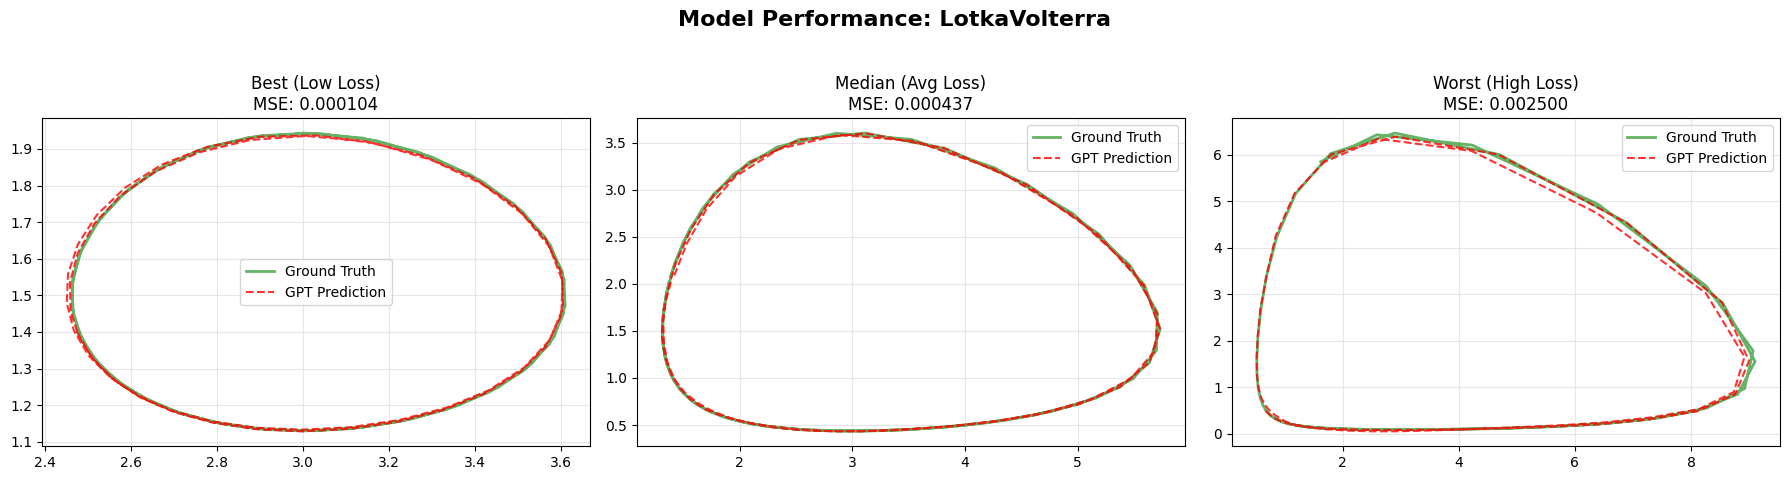

Generating comparison plots for LorenzAttractor...
Generating Lorenz System data (B=128, T=64)...


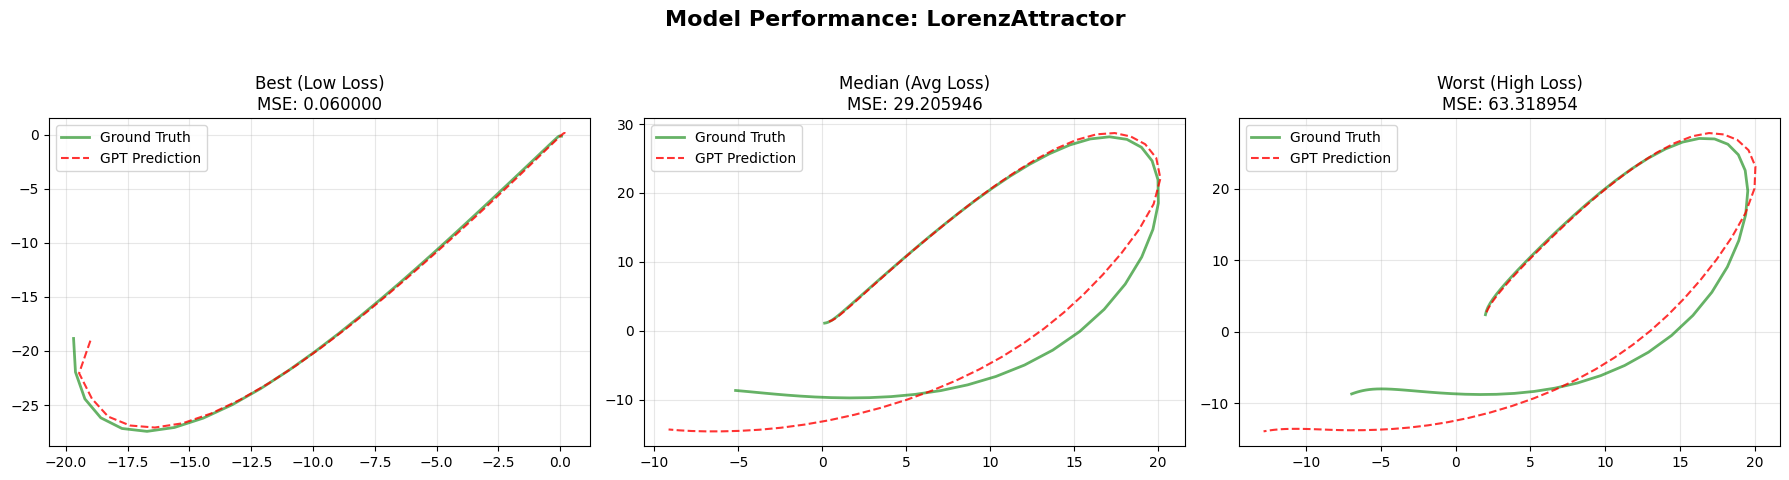

Generating comparison plots for KinematicBicycle...
Generating Kinematic Bicycle data (B=128, T=64)...


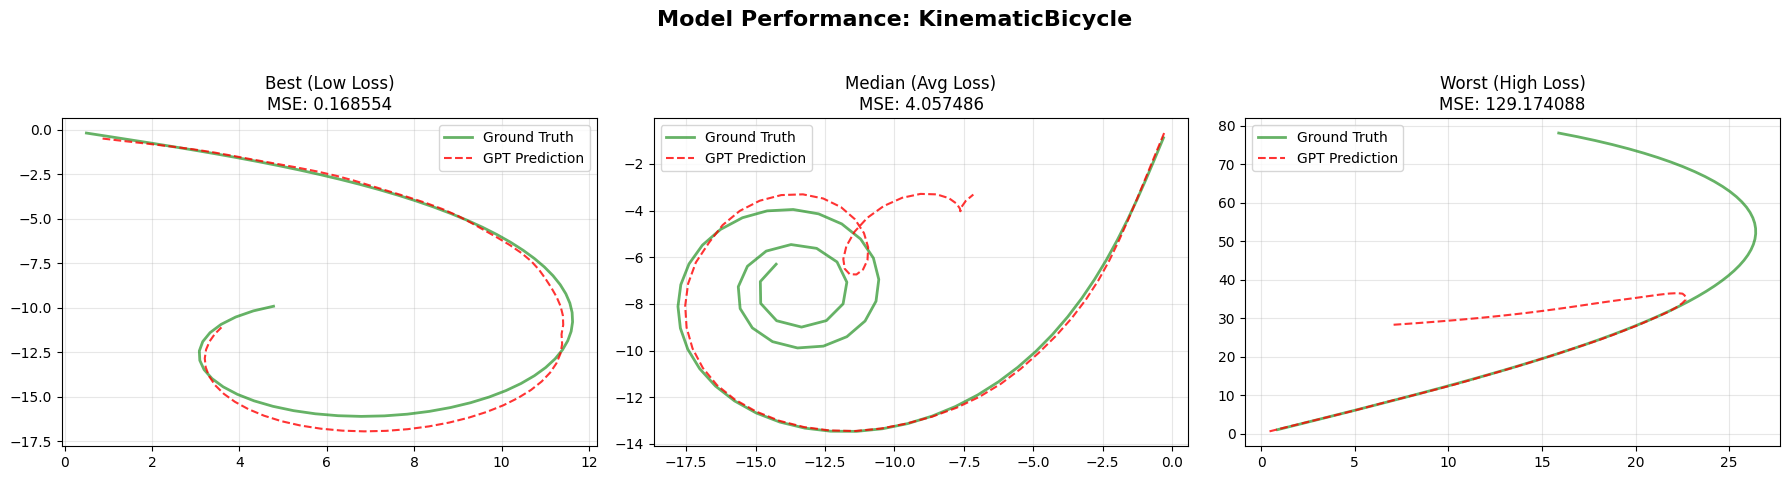

Generating comparison plots for TwoBodyOrbit...
Generating Two-Body Orbital data (B=128, T=64)...


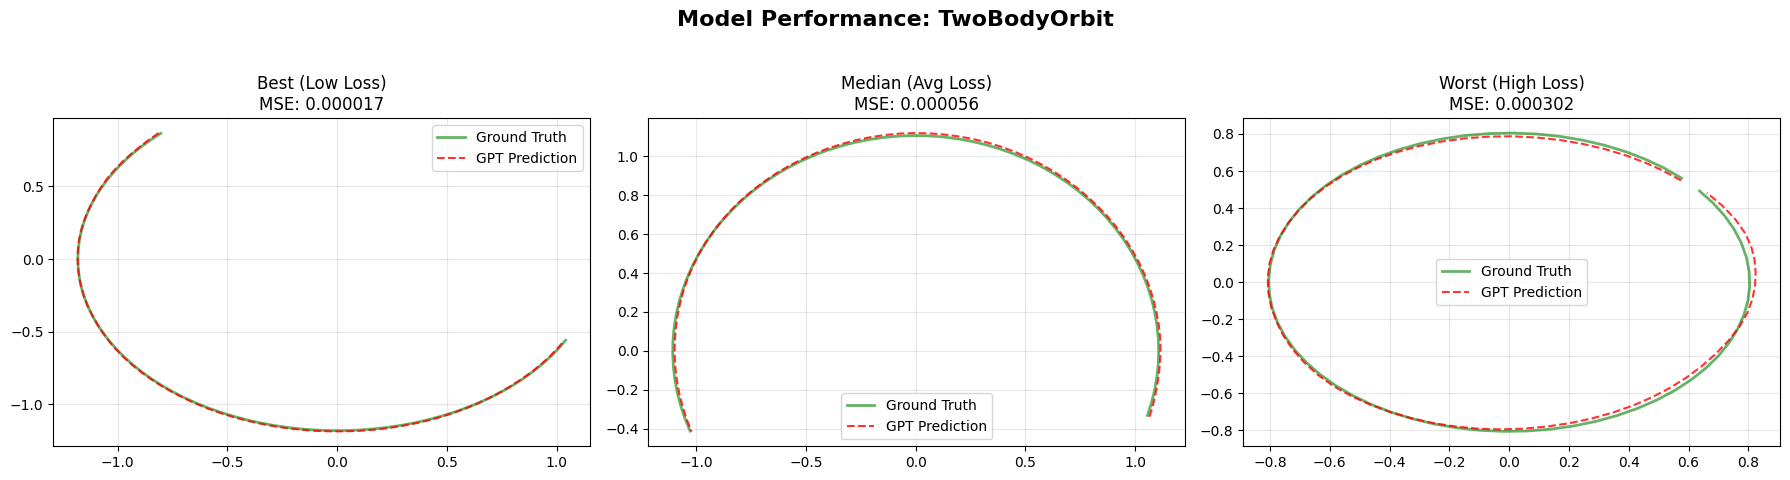

In [8]:
import matplotlib.pyplot as plt

# ==========================================
# 5. Visualization: Best, Average, and Worst
# ==========================================

def plot_physics_comparison(task_name, model, gen_func, norm_mean, norm_std, device):
    print(f"Generating comparison plots for {task_name}...")
    
    # 1. Generate a fresh batch of test data
    B_eval = 128 
    T_eval = 64
    # Ensure data is generated on CPU then moved
    data = gen_func(B=B_eval, T=T_eval).to(device)
    X = data[:, :-1, :]
    Y_true = data[:, 1:, :]
    
    # 2. Normalize and Predict
    X_norm = (X - norm_mean) / norm_std
    model.eval()
    with torch.no_grad():
        # One-step ahead prediction for loss ranking
        Y_pred_norm = model(X_norm)
        # Denormalize
        Y_pred = (Y_pred_norm * norm_std) + norm_mean
    
    # 3. Calculate MSE per trajectory to find Best, Median, Worst
    # Flatten B, T and calculate MSE per batch item
    mses = torch.mean((Y_pred - Y_true)**2, dim=(1, 2)) 
    sorted_indices = torch.argsort(mses)
    
    indices_to_plot = {
        "Best (Low Loss)": sorted_indices[0],
        "Median (Avg Loss)": sorted_indices[len(sorted_indices)//2],
        "Worst (High Loss)": sorted_indices[-1]
    }
    
    # 4. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Model Performance: {task_name}", fontsize=16, fontweight='bold')
    
    for i, (label, idx) in enumerate(indices_to_plot.items()):
        true_traj = Y_true[idx].cpu().numpy()
        pred_traj = Y_pred[idx].cpu().numpy()
        loss_val = mses[idx].item()
        
        # We plot the first 2 dimensions (usually x, y or x, v)
        axes[i].plot(true_traj[:, 0], true_traj[:, 1], 'g-', label='Ground Truth', alpha=0.6, linewidth=2)
        axes[i].plot(pred_traj[:, 0], pred_traj[:, 1], 'r--', label='GPT Prediction', alpha=0.8)
        
        axes[i].set_title(f"{label}\nMSE: {loss_val:.6f}")
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the visualization loop
for task_name, gen_func in tasks.items():
    filename = f"model_{task_name}.pt"
    if os.path.exists(filename):
        checkpoint = torch.load(filename, map_location=device, weights_only=False)
        model = GPT(checkpoint['config']).to(device)
        model.load_state_dict(checkpoint['model_state_dict'])
        
        plot_physics_comparison(
            task_name, 
            model, 
            gen_func, 
            checkpoint['norm_mean'].to(device), 
            checkpoint['norm_std'].to(device),
            device
        )
    else:
        print(f"Skipping {task_name}: No model file found.")